# Лабораторная работа 4

Линейные модели, SVM и деревья решений.
Цель лабораторной работы: изучение линейных моделей, SVM и деревьев решений.

# Датасет:
Текстовое описание набора данных
Набор данных по исследованию качества воздуха - https://archive.ics.uci.edu/dataset/360/air+quality

Набор содержит почасовые данные, полученные от комбинированного газоанализатора, установленного в итальянском городе вблизи автомобильной магистрали. Данные записывались с Марта 2004 по февраль 2005 (один год).

Датасет состоит из 2-х файлов одинаковых данных в формате .csv и .xlsx

Каждый файл содержит следующие колонки:

Date дата в формате ДЕНЬ-МЕСЯЦ-ГОД Набор данных содержит данные с интервалом измерения в один час.
Time время в формате ЧАСЫ:МИНУТЫ:СЕКУНДЫ.
CO(GT) концентрация СО mg/m^3
PT08.S1(CO) концентрация СО mg/m^3 усредненная за час
NMHC(GT) максимальная концентрация паров гидрокарбонатов усредненная за час microg/m^3
C6H6(GT) максимальная концентрация паров бензина усредненная за час microg/m^3
PT08.S2(NMHC) концентрация паров гидрокарбонатов усредненная за час microg/m^3
NOx(GT) максимальная концентрация оксидов азота усредненная за час microg/m^3
PT08.S3(NOx) концентрация оксидов азота усредненная за час microg/m^3
NO2(GT) максимальная концентрация двуокиси азота усредненная за час microg/m^3
PT08.S4(NO2) концентрация двуокиси азота усредненная за час microg/m^3
PT08.S5(O3) концентрация озона усредненная за час microg/m^3
T температура в градусах Цельсия
RH относительная влажность в %.
AH абсолютная влажность в %.
Category категория качества воздуха - Good/Bad


In [62]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import KFold, RepeatedKFold, LeaveOneOut, LeavePOut, ShuffleSplit, StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit
from sklearn.model_selection import ValidationCurveDisplay
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC, NuSVC, LinearSVC, OneClassSVM, SVR, NuSVR, LinearSVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz

from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

In [63]:
# 
data = pd.read_csv('air+quality/2.csv', sep=";")
data = data.drop(columns=['Unnamed: 16'])

In [64]:
# Первые 5 строк датасета
data.head()

,Date,Time,COGT,PT08S1CO,NMHCGT,C6H6GT,PT08S2NMHC,NOxGT,PT08S3NOx,NO2GT,PT08S4NO2,PT08S5O3,T,RH,AH,Category
0,10.03.2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268,13.6,48.9,0.7578,Bad
1,10.03.2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972,13.3,47.7,0.7255,Bad
2,10.03.2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074,11.9,54.0,0.7502,Bad
3,10.03.2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203,11.0,60.0,0.7867,Bad
4,10.03.2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110,11.2,59.6,0.7888,Good


In [65]:
#Удаление строк с пропусками
data = data.dropna(axis=0, how='any')
data.shape

(827, 16)

In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 827 entries, 0 to 1230
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        827 non-null    object 
 1   Time        827 non-null    object 
 2   COGT        827 non-null    float64
 3   PT08S1CO    827 non-null    float64
 4   NMHCGT      827 non-null    float64
 5   C6H6GT      827 non-null    float64
 6   PT08S2NMHC  827 non-null    float64
 7   NOxGT       827 non-null    float64
 8   PT08S3NOx   827 non-null    float64
 9   NO2GT       827 non-null    float64
 10  PT08S4NO2   827 non-null    float64
 11  PT08S5O3    827 non-null    int64  
 12  T           827 non-null    float64
 13  RH          827 non-null    float64
 14  AH          827 non-null    float64
 15  Category    827 non-null    object 
dtypes: float64(12), int64(1), object(3)
memory usage: 109.8+ KB


In [67]:
data.describe()

,COGT,PT08S1CO,NMHCGT,C6H6GT,PT08S2NMHC,NOxGT,PT08S3NOx,NO2GT,PT08S4NO2,PT08S5O3,T,RH,AH
count,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000
mean,2.353567,1207.879081,231.025393,10.771100,966.116082,143.501814,963.297461,100.259976,1600.620314,1045.812576,15.601451,49.050181,0.831853
std,1.409496,241.816997,208.461912,7.418134,266.424557,81.829717,265.914168,31.493823,302.291793,400.134662,4.825304,15.266746,0.178506
min,0.300000,753.000000,7.000000,0.500000,448.000000,12.000000,461.000000,19.000000,955.000000,263.000000,6.300000,14.900000,0.402300
25%,1.300000,1017.000000,77.000000,4.800000,754.000000,81.000000,769.000000,78.500000,1369.500000,760.000000,11.900000,36.700000,0.718950
50%,2.000000,1172.000000,157.000000,9.100000,944.000000,128.000000,920.000000,99.000000,1556.000000,1009.000000,15.000000,49.600000,0.817700
75%,3.100000,1380.000000,318.500000,14.800000,1142.500000,187.000000,1131.000000,122.000000,1783.500000,1320.000000,18.300000,60.550000,0.927500
max,8.100000,2040.000000,1189.000000,39.200000,1754.000000,478.000000,1935.000000,196.000000,2679.000000,2359.000000,30.000000,83.200000,1.485200


# Линейная регрессия
## Наличие корреляций в данных

<Axes: xlabel='COGT', ylabel='C6H6GT'>

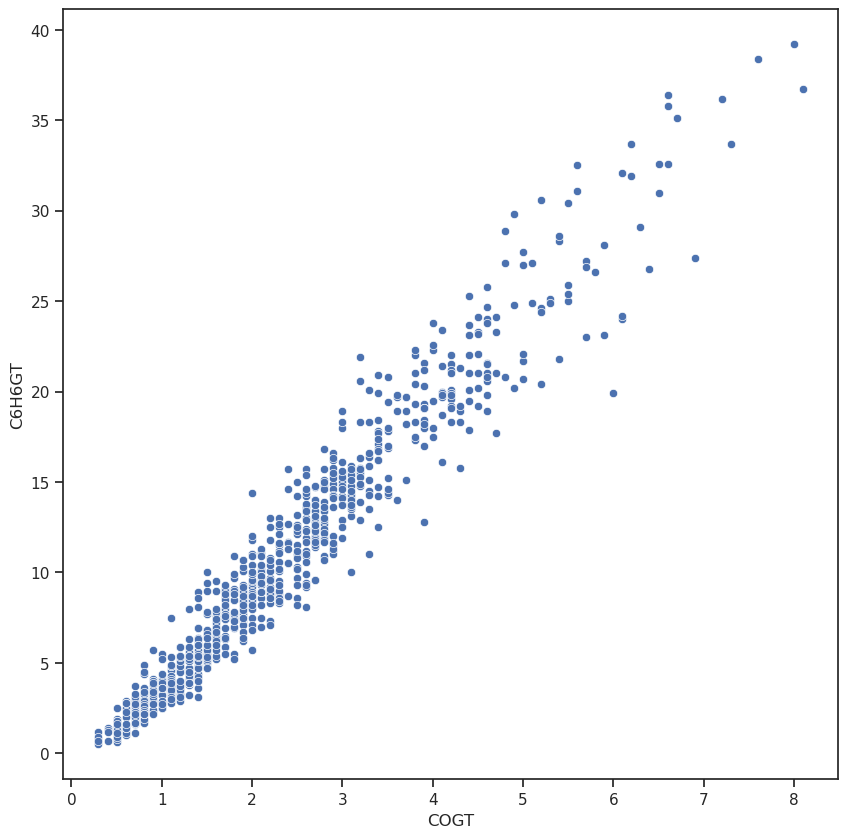

In [68]:
fig, ax = plt.subplots(figsize=(10,10)) 

sns.scatterplot(ax=ax, x='COGT', y='C6H6GT', data=data)

## Корреляция присутствует

In [69]:
# Аналитическое вычисление коэффициентов регрессии
def analytic_regr_coef(x_array : np.ndarray, 
                       y_array : np.ndarray) -> Tuple[float, float]:
    x_mean = np.mean(x_array)
    y_mean = np.mean(y_array)
    var1 = np.sum([(x-x_mean)**2 for x in x_array])
    cov1 = np.sum([(x-x_mean)*(y-y_mean) for x, y in zip(x_array, y_array)])
    b1 = cov1 / var1
    b0 = y_mean - b1*x_mean
    return b0, b1

In [70]:
X=data['COGT'].values

In [71]:
Y=data['C6H6GT'].values

In [72]:
b0, b1 = analytic_regr_coef(X, Y)
b0, b1

(np.float64(-1.2769914313894049), np.float64(5.119077226551088))

In [73]:
# Вычисление значений y на основе x для регрессии
def y_regr(x_array : np.ndarray, b0: float, b1: float) -> np.ndarray:
    res = [b1*x+b0 for x in x_array]
    return res

In [74]:
Y_regr = y_regr(X, b0, b1)

In [75]:
# Разделение выборки на обучающую и тестовую

In [76]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y , test_size = 0.3, random_state= 1)

In [77]:
# Размер обучающей выборки
X_train.shape, Y_train.shape

((578,), (578,))

In [78]:
# Размер тестовой выборки
X_test.shape, Y_test.shape

((249,), (249,))

In [79]:
# Обучим линейную регрессию
reg1 = LinearRegression().fit(X_train.reshape(-1, 1), Y_train.reshape(-1, 1))
(b1, reg1.coef_), (b0, reg1.intercept_)

((np.float64(5.119077226551088), array([[5.15390157]])),
 (np.float64(-1.2769914313894049), array([-1.29321071])))

In [80]:
target = reg1.predict(X_test.reshape(-1, 1))
target.shape

(249, 1)

In [81]:
Y_pred = y_regr(X, reg1.intercept_[0], reg1.coef_[0])

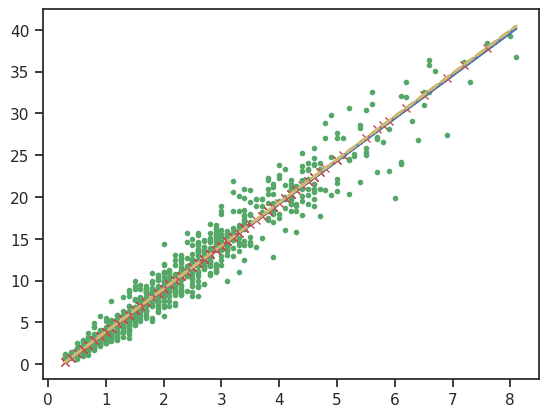

In [82]:
plt.plot(X, Y, 'g.')
plt.plot(X, Y_regr, 'b', linewidth=2.0)
plt.plot(X_test,target, 'rx')
plt.plot(X, Y_pred, 'y--', linewidth=2.0)
plt.show()

# SVM

In [83]:
def plot_regr(clf):
    title = clf.__repr__
    clf.fit(X.reshape(-1, 1), Y)
    Y_pred_svm = clf.predict(X.reshape(-1, 1))
    fig, ax = plt.subplots(figsize=(5,5))
    ax.set_title(title)
    ax.plot(X, Y, 'b.')
    ax.plot(X, Y_pred_svm, 'ro')
    plt.show()

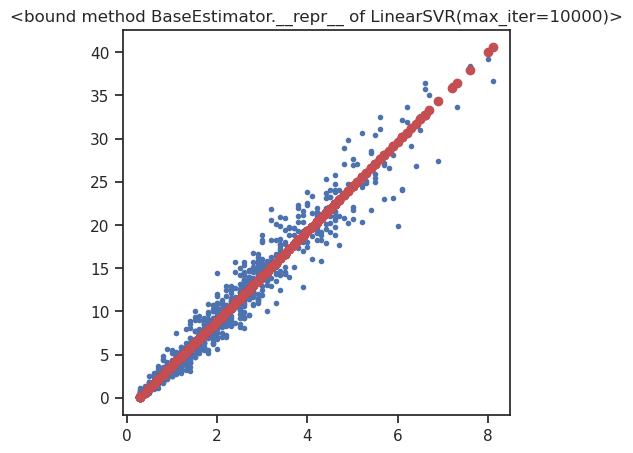

In [84]:
plot_regr(LinearSVR(C=1.0, max_iter=10000))

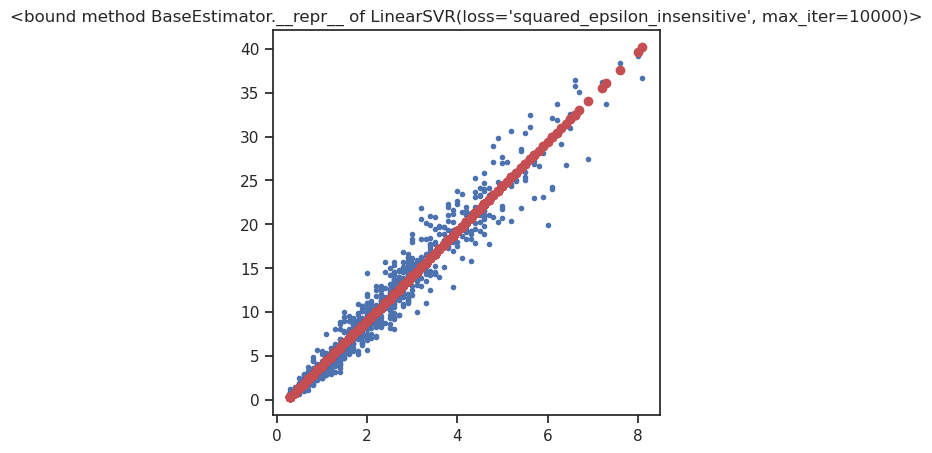

In [85]:
plot_regr(LinearSVR(C=1.0, loss='squared_epsilon_insensitive', max_iter=10000))

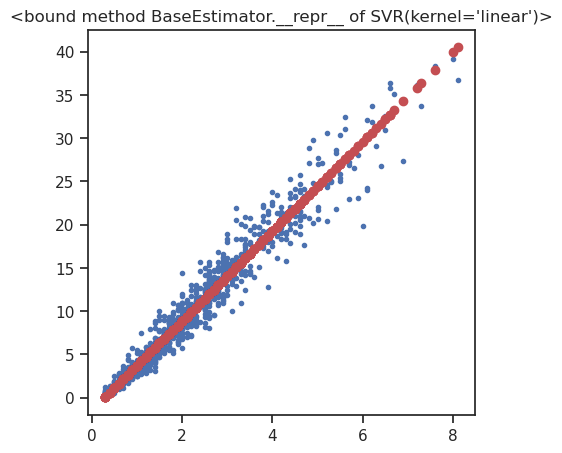

In [86]:
plot_regr(SVR(kernel='linear', C=1.0))

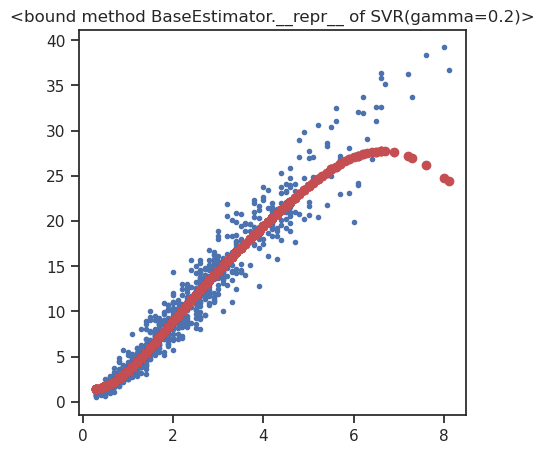

In [87]:
plot_regr(SVR(kernel='rbf', gamma=0.2, C=1.0))

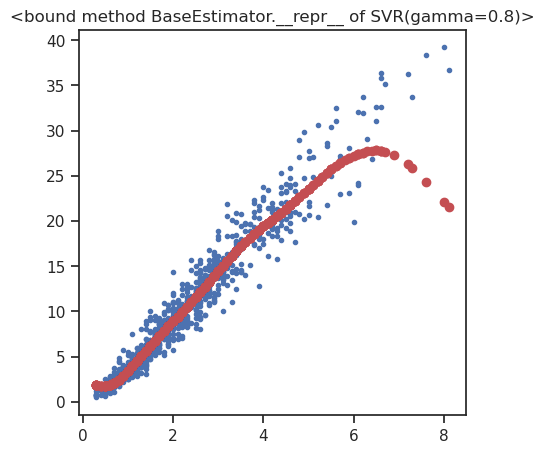

In [88]:
plot_regr(SVR(kernel='rbf', gamma=0.8, C=1.0))

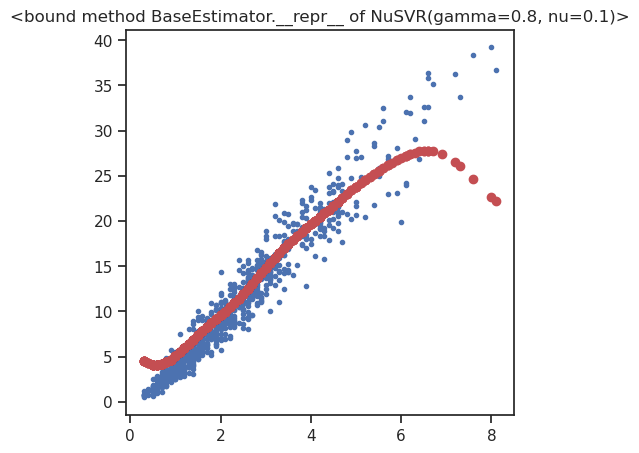

In [89]:
plot_regr(NuSVR(kernel='rbf', gamma=0.8, nu=0.1, C=1.0))

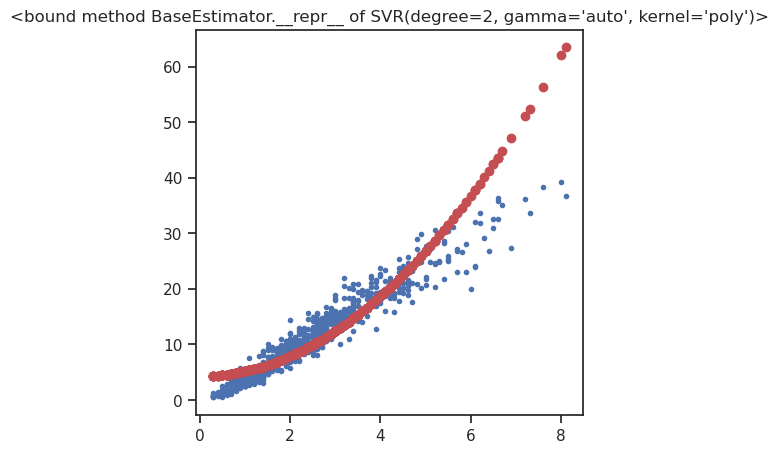

In [90]:
plot_regr(SVR(kernel='poly', degree=2, gamma='auto', C=1.0))

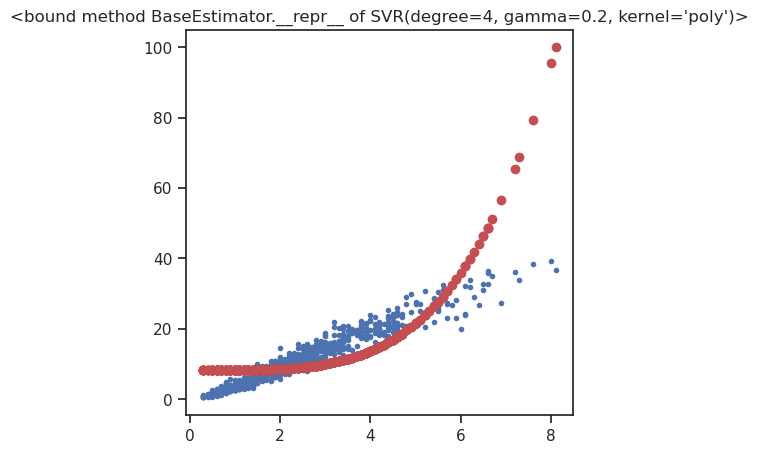

In [91]:
plot_regr(SVR(kernel='poly', degree=4, gamma=0.2, C=1.0))

## Модель без масштабирования данных

In [92]:
svr_1 = SVR()
svr_1.fit(X_train.reshape(-1, 1), Y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [93]:
Y_pred_svr1 = svr_1.predict(X_test.reshape(-1, 1))

In [94]:
mean_absolute_error(Y_test, Y_pred_svr1), mean_squared_error(Y_test, Y_pred_svr1)

(1.2864504059839514, 4.270987050051196)

## Модель с масштабированием данных

In [95]:
# Масштабирование данных в диапазоне от 0 до 1
data1=data[['COGT','C6H6GT']]
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data1)

### Разделение выборки на обучающую и тестовую

In [96]:
X1=data1['COGT'].values

In [97]:
Y1=data1['C6H6GT'].values

In [98]:
X_train_1, X_test_1, Y_train_1, Y_test_1 = train_test_split(
    X1, Y1, test_size=0.2, random_state=1)

X_train_1.shape, X_test_1.shape

((661,), (166,))

In [99]:
svr_2 = SVR()
svr_2.fit(X_train_1.reshape(-1, 1), Y_train_1)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [100]:
Y_pred_svr2 = svr_2.predict(X_test_1.reshape(-1, 1))

In [101]:
mean_absolute_error(Y_test_1, Y_pred_svr2), mean_squared_error(Y_test_1, Y_pred_svr2)

(1.4357329299537565, 5.479823336504155)

## Кросс валидация

In [102]:
scoring = {'MAE': 'neg_mean_absolute_error', 
           'MSE': 'neg_mean_squared_error'}

In [103]:
scores_1 = cross_validate(SVR(), 
                        X.reshape(-1, 1), Y, scoring=scoring, 
                        cv=3, return_train_score=True)
scores_1

{'fit_time': array([0.00712013, 0.00797462, 0.00815964]),
 'score_time': array([0.00463724, 0.00503659, 0.004529  ]),
 'test_MAE': array([-1.47578098, -0.95884391, -1.77559536]),
 'train_MAE': array([-1.36011649, -1.49405171, -1.12475737]),
 'test_MSE': array([-8.88549747, -1.6853497 , -5.83145136]),
 'train_MSE': array([-4.24078026, -5.1718752 , -3.54627131])}

In [104]:

-np.mean(scores_1['train_MAE']), -np.mean(scores_1['test_MAE']), \
-np.mean(scores_1['train_MSE']), -np.mean(scores_1['test_MSE'])

(np.float64(1.3263085228318563),
 np.float64(1.4034067491559625),
 np.float64(4.319642257736464),
 np.float64(5.467432845873874))

# Деревья решений

In [105]:
#Преобразование категориальных признаков в числовые
from sklearn.preprocessing import OrdinalEncoder
data_oe = data[['Category']]
oe = OrdinalEncoder()
enc_oe = oe.fit_transform(data_oe)

In [106]:
# Визуализация дерева
def get_png_tree(tree_model_param, feature_names_param):
    dot_data = StringIO()
    export_graphviz(tree_model_param, out_file=dot_data, feature_names=feature_names_param,
                    filled=True, rounded=True, special_characters=True)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    return graph.create_png()

In [107]:
def accuracy_score_for_classes(
    y_true: np.ndarray, 
    y_pred: np.ndarray) -> Dict[int, float]:
    """
    Вычисление метрики accuracy для каждого класса
    y_true - истинные значения классов
    y_pred - предсказанные значения классов
    Возвращает словарь: ключ - метка класса, 
    значение - Accuracy для данного класса
    """
    # Для удобства фильтрации сформируем Pandas DataFrame 
    d = {'t': y_true, 'p': y_pred}
    df = pd.DataFrame(data=d)
    # Метки классов
    classes = np.unique(y_true)
    # Результирующий словарь
    res = dict()
    # Перебор меток классов
    for c in classes:
        # отфильтруем данные, которые соответствуют 
        # текущей метке класса в истинных значениях
        temp_data_flt = df[df['t']==c]
        # расчет accuracy для заданной метки класса
        temp_acc = accuracy_score(
            temp_data_flt['t'].values, 
            temp_data_flt['p'].values)
        # сохранение результата в словарь
        res[c] = temp_acc
    return res

def print_accuracy_score_for_classes(
    y_true: np.ndarray, 
    y_pred: np.ndarray):
    """
    Вывод метрики accuracy для каждого класса
    """
    accs = accuracy_score_for_classes(y_true, y_pred)
    if len(accs)>0:
        print('Метка \t Accuracy')
    for i in accs:
        print('{} \t {}'.format(i, accs[i]))

In [108]:
def plot_tree_classification(title_param, ds):
    """
    Построение деревьев и вывод графиков для заданного датасета
    """
    
    n_classes = len(np.unique(enc_oe[:, 0]))
    plot_colors = "ryb"
    plot_step = 0.02
    
    for pairidx, pair in enumerate([['COGT', 'C6H6GT'], ['COGT', 'NOxGT'], ['COGT', 'NO2GT'],
                                    ['C6H6GT', 'NOxGT'], ['C6H6GT','NO2GT']]):
        # We only take the two corresponding features
        X = ds[pair]
        y = enc_oe[:, 0]

        # Train
        clf = DecisionTreeClassifier(random_state=1).fit(X.to_numpy(), y)

        plt.title(title_param)

        x_min, x_max = X[pair[0]].min()-1, X[pair[0]].max()+1
        y_min, y_max = X[pair[1]].min()-1, X[pair[1]].max()+1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                             np.arange(y_min, y_max, plot_step))
        plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        cs = plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu)

        plt.xlabel(pair[0])
        plt.ylabel(pair[1])

        # Plot the training points
        for i, color in zip(range(n_classes), plot_colors):
            idx = np.where(y == i)
            plt.scatter(X[pair[0]], X[pair[1]], c=color,
                         edgecolor='black', s=15)

        plt.show()    

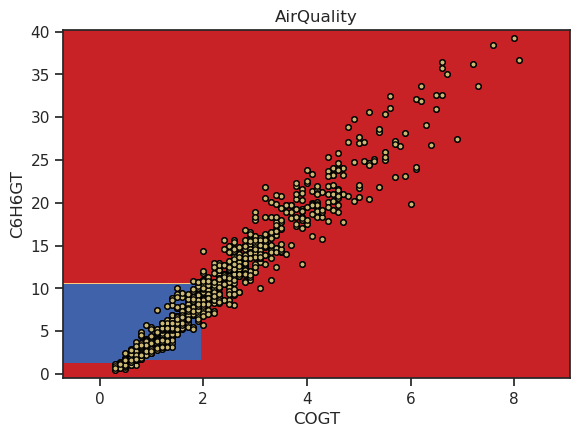

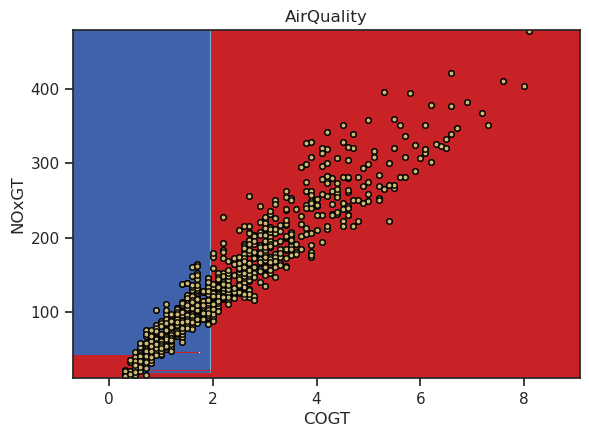

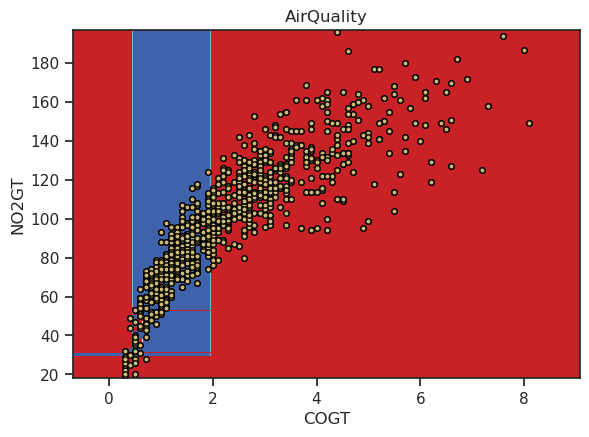

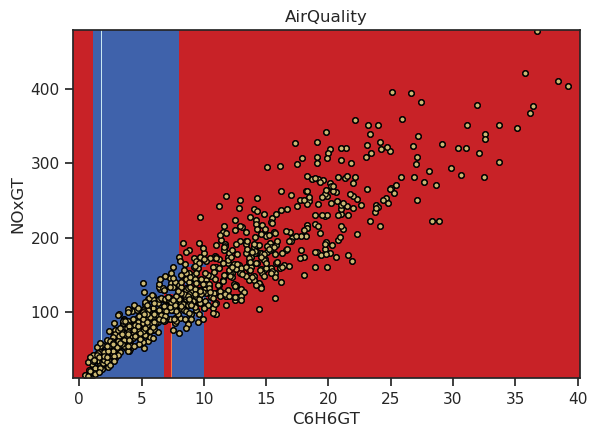

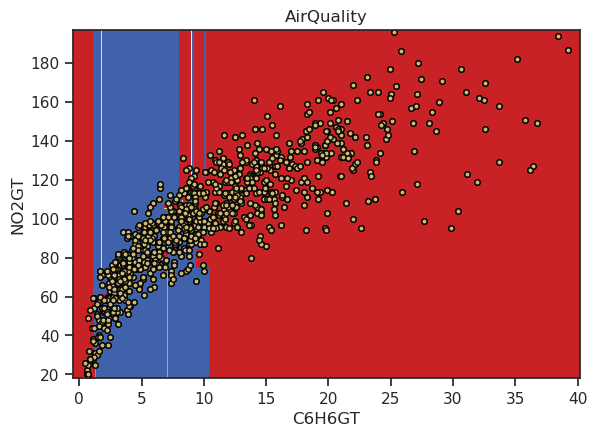

In [109]:
plot_tree_classification('AirQuality', data)

In [110]:
# Обучим дерево на всех четырех признаках
X = data[['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']]
y = enc_oe[:, 0]
air_tree = DecisionTreeClassifier(random_state=1).fit(X.to_numpy(), y)
air_tree

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Вывод правил дерева в текстовом виде

In [111]:
from IPython.core.display import HTML
from sklearn.tree import export_text
tree_rules = export_text(air_tree, feature_names=['COGT', 'C6H6GT', 'NOxGT', 'NO2GT'])
HTML('<pre>' + tree_rules + '</pre>')

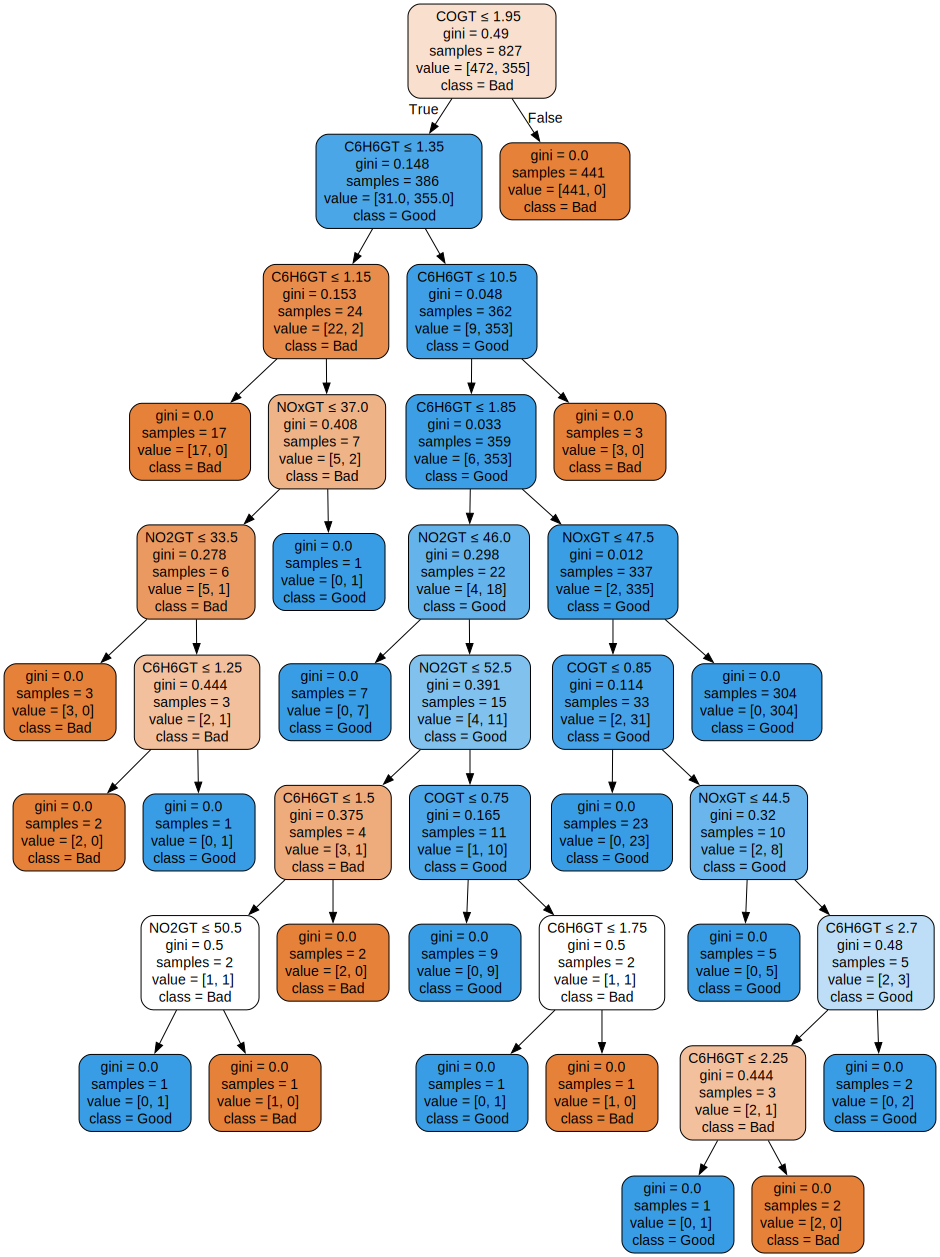

In [112]:
import graphviz
dot_data = export_graphviz(air_tree, out_file=None, 
                           feature_names=['COGT', 'C6H6GT', 'NOxGT', 'NO2GT'], 
                           class_names=np.unique(data_oe), 
                           filled=True, rounded=True, special_characters=True)  
graph = graphviz.Source(dot_data)  
graph

## Важность признаков

In [113]:
list(zip(X.values, air_tree.feature_importances_))

[(array([  2.6,  11.9, 166. , 113. ]), np.float64(0.8626808654176965)),
 (array([  2. ,   9.4, 103. ,  92. ]), np.float64(0.12061288660351346)),
 (array([  2.2,   9. , 131. , 114. ]), np.float64(0.005451708673104865)),
 (array([  2.2,   9.2, 172. , 122. ]), np.float64(0.01125453930568516))]

In [114]:
# Важность признаков в сумме дает единицу
sum(air_tree.feature_importances_)

np.float64(1.0)

In [115]:
from operator import itemgetter

def draw_feature_importances(tree_model, X_dataset, figsize=(18,5)):
    """
    Вывод важности признаков в виде графика
    """
    # Сортировка значений важности признаков по убыванию
    list_to_sort = list(zip(X_dataset.columns.values, tree_model.feature_importances_))
    sorted_list = sorted(list_to_sort, key=itemgetter(1), reverse = True)
    # Названия признаков
    labels = [x for x,_ in sorted_list]
    # Важности признаков
    data = [x for _,x in sorted_list]
    # Вывод графика
    fig, ax = plt.subplots(figsize=figsize)
    ind = np.arange(len(labels))
    plt.bar(ind, data)
    plt.xticks(ind, labels, rotation='vertical')
    # Вывод значений
    for a,b in zip(ind, data):
        plt.text(a-0.05, b+0.01, str(round(b,3)))
    plt.show()
    return labels, data

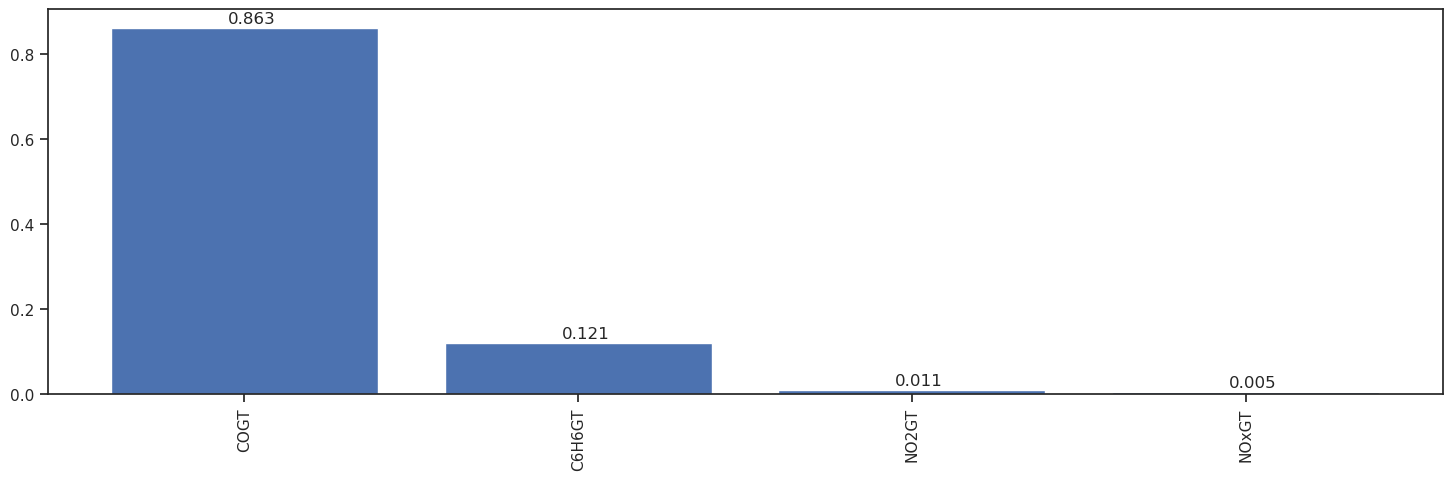

In [116]:
air_tree_fl, air_tree_fd = draw_feature_importances(air_tree, X)